In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN



In [4]:
df = pd.read_csv("Fraud Detection Dataset.csv")

In [5]:
print(list(df.columns))

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


# Partition

In [6]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=42)
len(partition)

35700

# Random 

In [7]:
sample_random = df.sample(n=100)
sample_random.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
49022,T49023,4660,3448.63,Bank Transfer,13.0,Mobile,Houston,4,5,12,Credit Card,0
41423,T41424,1751,2456.06,POS Payment,15.0,Mobile,Miami,1,102,6,Net Banking,0
28844,T28845,1594,2249.36,Bill Payment,19.0,Desktop,Houston,1,113,10,Credit Card,0
31792,T31793,3226,2026.68,Online Purchase,16.0,Tablet,Seattle,1,83,12,UPI,0
24126,T24127,3161,134.29,POS Payment,19.0,Mobile,Chicago,1,37,6,UPI,0


# stratified

In [9]:
sample_stratified = (
    df.groupby("Location", group_keys=False)
      .apply(lambda x: x.sample(frac=0.1, random_state=42))
)
print(sample_stratified["Location"].value_counts())
sample_stratified.head()

Location
Boston           615
New York         611
Seattle          610
Chicago          607
Houston          603
Los Angeles      601
Miami            599
San Francisco    598
Name: count, dtype: int64


C:\Users\piyus\AppData\Local\Temp\ipykernel_60348\3698432622.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.1, random_state=42))


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
23597,T23598,2623,24.05,Bank Transfer,5.0,Tablet,Boston,2,48,14,Net Banking,0
50817,T1508,3062,4546.33,Bill Payment,5.0,Tablet,Boston,4,28,11,Invalid Method,0
43719,T43720,4328,NaN,Online Purchase,NaN,NaN,Boston,1,7,11,NaN,0
40025,T40026,1565,4865.36,Bank Transfer,22.0,Mobile,Boston,0,95,6,Debit Card,0
41638,T41639,3276,3711.51,Bank Transfer,NaN,Tablet,Boston,0,56,8,Credit Card,0


# Cluster 

In [10]:
locations = df["Location"].dropna().unique()
selected_locations = pd.Series(locations).sample(n=2, random_state=42)
sample_cluster = df[df["Location"].isin(selected_locations)]
print(selected_locations.tolist())
sample_cluster.head()

['New York', 'Miami']


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
16,T17,4171,3960.52,Bank Transfer,13.0,Tablet,Miami,2,68,8,Debit Card,0
17,T18,3919,2327.71,Online Purchase,20.0,NaN,Miami,4,21,1,Debit Card,0
20,T21,2685,973.51,Bill Payment,2.0,Mobile,New York,1,43,12,UPI,0
21,T22,4380,2553.98,ATM Withdrawal,3.0,Mobile,Miami,1,7,9,Net Banking,0


In [11]:
#Data Selection

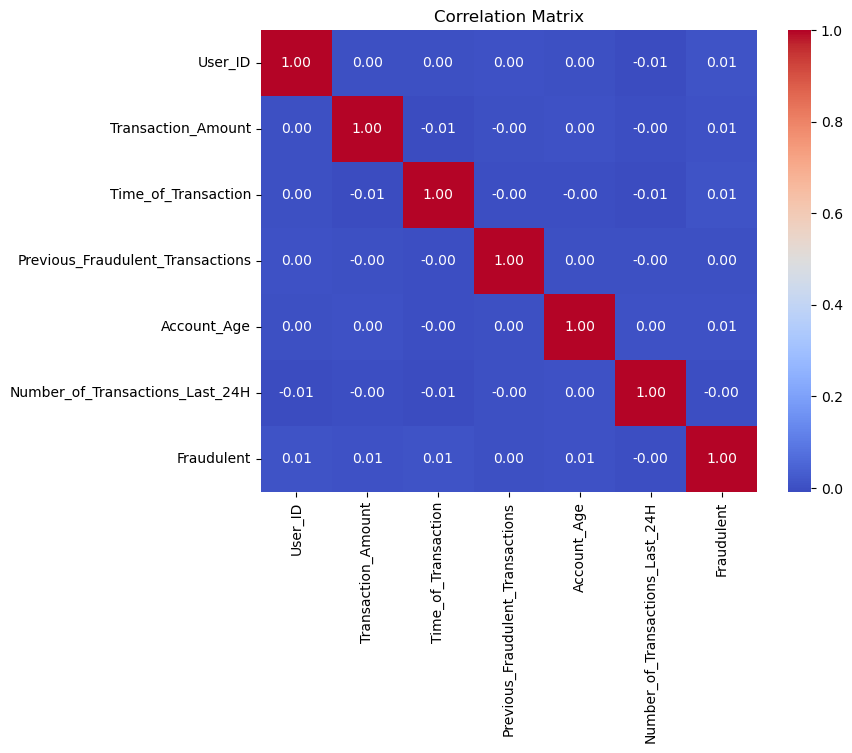

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [15]:
from sklearn.feature_selection import chi2, SelectKBest

# 1. Prepare data (drop ID columns: they carry no signal)
data = df.drop(columns=['Transaction_ID', 'User_ID'])

num_cols = data.select_dtypes(include='number').columns.drop('Fraudulent')
cat_cols = data.select_dtypes(exclude='number').columns

# 2. Fill missing values
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

# 3. Encode text columns as numbers
for c in cat_cols:
    data[c] = data[c].astype('category').cat.codes

# 4. Features and target
X = data.drop('Fraudulent', axis=1)
Y = data['Fraudulent']

# 5. Chi-square test
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X, Y)

result = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('Chi2 Score', ascending=False)
print(result.to_string(index=False))

                         Feature   Chi2 Score      p-value
              Transaction_Amount 11918.382002 0.000000e+00
                     Account_Age    38.641759 5.091780e-10
             Time_of_Transaction     9.609652 1.935573e-03
                        Location     6.067080 1.377245e-02
                Transaction_Type     2.573896 1.086399e-01
 Number_of_Transactions_Last_24H     1.652434 1.986280e-01
                     Device_Used     0.655608 4.181148e-01
                  Payment_Method     0.155549 6.932882e-01
Previous_Fraudulent_Transactions     0.065995 7.972595e-01


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)
print(X_train.shape, X_test.shape)

KeyError: "['Fraud'] not found in axis"

In [ ]:
#Split

Task 5: 
ML Model